In [1]:
from herbie import Herbie
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Coordenadas oficiales del Observatorio Astronómico de Quito (OAQ)
LAT_OAQ = -0.2150
LON_OAQ = -78.5025

# Ajuste automático de longitud para la malla global GFS (0° -> 360°)
LON_OAQ_GFS = LON_OAQ % 360

print("============================================================")
print("             CONFIGURACIÓN DE COORDENADAS OAQ               ")
print("============================================================")
print(f"Coordenadas WGS84:  Lat: {LAT_OAQ:.4f}, Lon: {LON_OAQ:.4f}")
print(f"Coordenadas GFS:    Lat: {LAT_OAQ:.4f}, Lon: {LON_OAQ_GFS:.4f}")

             CONFIGURACIÓN DE COORDENADAS OAQ               
Coordenadas WGS84:  Lat: -0.2150, Lon: -78.5025
Coordenadas GFS:    Lat: -0.2150, Lon: 281.4975


In [2]:
# Conexión al servidor de NOAA/AWS para el estado inicial (F00)
H = Herbie("2026-05-10 00:00", model="gfs", product="pgrb2.0p25", fxx=0)

# Descarga e interpretación del mensaje GRIB2 específico para RH a 700 mb
ds_rh700 = H.xarray(":RH:700 mb:")
da_rh700 = ds_rh700["r"]  # Extraer el DataArray de la variable 'r'

print("============================================================")
print("             METADATOS Y ESTADÍSTICOS GLOBALES GFS          ")
print("============================================================")
print(f"Dimensiones de la malla global: {da_rh700.shape} (Lat x Lon)")
print(f"Rango de Humedad Relativa:     Min: {float(da_rh700.min()):.1f}% | Max: {float(da_rh700.max()):.1f}%")
print(f"Humedad Relativa Promedio:     {float(da_rh700.mean()):.2f}%")

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
             METADATOS Y ESTADÍSTICOS GLOBALES GFS          
Dimensiones de la malla global: (721, 1440) (Lat x Lon)
Rango de Humedad Relativa:     Min: 0.0% | Max: 100.0%
Humedad Relativa Promedio:     55.27%


In [3]:
rh700_oaq = da_rh700.interp(latitude=LAT_OAQ, longitude=LON_OAQ_GFS)

# Localizar el nodo de malla pura más cercano para el control de calidad
nodo_cercano = da_rh700.sel(latitude=LAT_OAQ, longitude=LON_OAQ_GFS, method="nearest")

print("============================================================")
print("             EXTRACCIÓN PUNTUAL SOBRE EL OAQ                ")
print("============================================================")
print(f"Valor interpolado (OAQ):           {float(rh700_oaq.values):.2f} %")
print(f"Nodo de malla GFS más cercano:     Lat: {float(nodo_cercano.latitude):.2f}, Lon: {float(nodo_cercano.longitude):.2f}")
print(f"Valor en el nodo más cercano:      {float(nodo_cercano.values):.2f} %")

             EXTRACCIÓN PUNTUAL SOBRE EL OAQ                
Valor interpolado (OAQ):           78.06 %
Nodo de malla GFS más cercano:     Lat: -0.25, Lon: 281.50
Valor en el nodo más cercano:      75.50 %


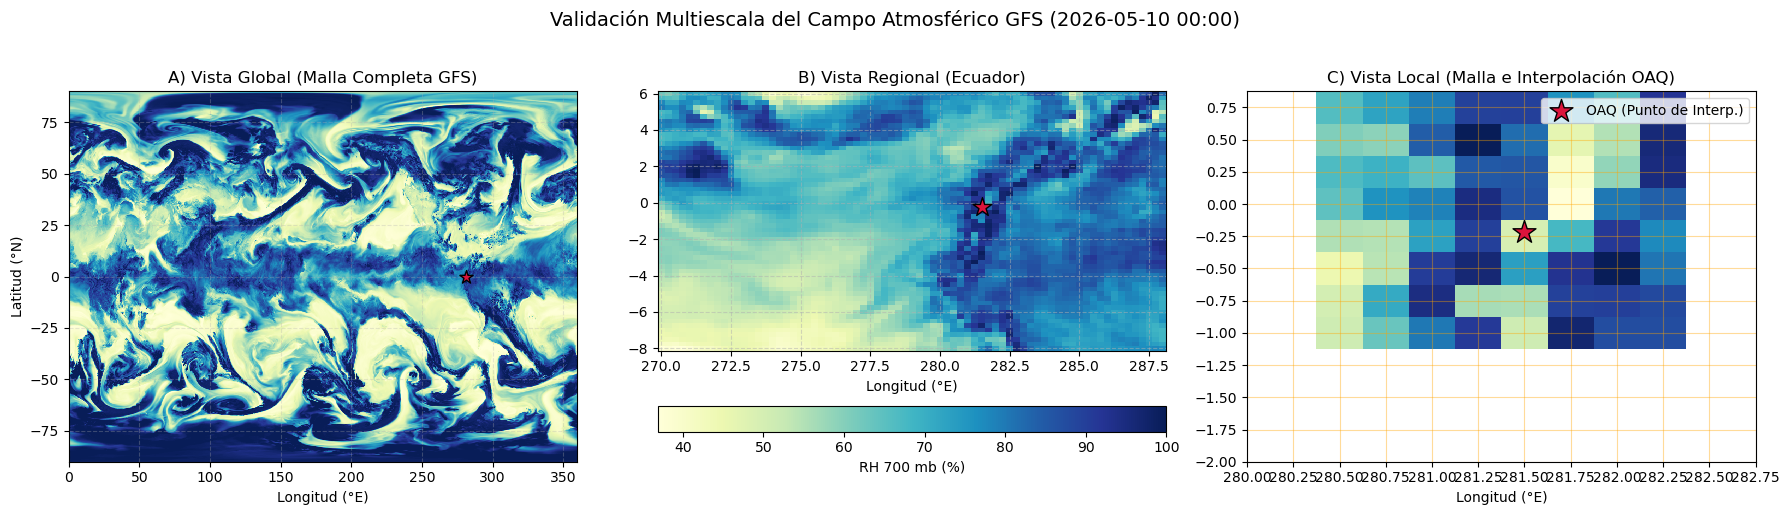

In [9]:
# Crear una figura con 3 subplots en paralelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================
# 1. ESCALA GLOBAL
# ============================================================
da_rh700.plot(ax=axes[0], cmap="YlGnBu", add_colorbar=False)
axes[0].scatter(LON_OAQ_GFS, LAT_OAQ, color="crimson", marker="*", s=100, edgecolor="black", zorder=5)
axes[0].set_title("A) Vista Global (Malla Completa GFS)")
axes[0].set_xlabel("Longitud (°E)")
axes[0].set_ylabel("Latitud (°N)")
axes[0].grid(True, linestyle="--", alpha=0.3)

# ============================================================
# 2. ESCALA REGIONAL (Zoom sobre Ecuador y países vecinos)
# ============================================================
da_rh700.sel(
    latitude=slice(6, -8),       # Norte a Sur
    longitude=slice(270, 288)    # Oeste a Este
).plot(ax=axes[1], cmap="YlGnBu", cbar_kwargs={"label": "RH 700 mb (%)", "orientation": "horizontal", "pad": 0.15})
axes[1].scatter(LON_OAQ_GFS, LAT_OAQ, color="crimson", marker="*", s=200, edgecolor="black", zorder=5)
axes[1].set_title("B) Vista Regional (Ecuador)")
axes[1].set_xlabel("Longitud (°E)")
axes[1].set_ylabel("") # Ocultar para evitar saturación visual
axes[1].grid(True, linestyle="--", alpha=0.5)

# ============================================================
# 3. ESCALA LOCAL (Zoom de alta resolución a los píxeles vecinos)
# ============================================================
# Recortamos a una ventana de apenas 1.5 grados alrededor del observatorio
da_rh700.sel(
    latitude=slice(LAT_OAQ + 1.0, LAT_OAQ - 1.0),
    longitude=slice(LON_OAQ_GFS - 1.0, LON_OAQ_GFS + 1.0)
).plot(ax=axes[2], cmap="YlGnBu", add_colorbar=False)

# Dibujar las líneas de la malla GFS para ver la intersección de las celdas de 0.25°
axes[2].set_xticks(np.arange(np.floor(LON_OAQ_GFS - 1), np.ceil(LON_OAQ_GFS + 1), 0.25))
axes[2].set_yticks(np.arange(np.floor(LAT_OAQ - 1), np.ceil(LAT_OAQ + 1), 0.25))

# Graficar el punto exacto interpolado (OAQ)
axes[2].scatter(
    LON_OAQ_GFS, LAT_OAQ, 
    color="crimson", marker="*", s=300, edgecolor="black", zorder=5, 
    label="OAQ (Punto de Interp.)"
)
axes[2].set_title("C) Vista Local (Malla e Interpolación OAQ)")
axes[2].set_xlabel("Longitud (°E)")
axes[2].set_ylabel("")
axes[2].grid(True, color="orange", linestyle="-", alpha=0.4) # Malla GFS en color para resaltar
axes[2].legend(loc="upper right")

# Ajustes generales de la composición
plt.suptitle(f"Validación Multiescala del Campo Atmosférico GFS ({fecha_prueba})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
print("Latitud OAQ:", LAT_OAQ)
print("Longitud OAQ GFS:", LON_OAQ_GFS)

print("\nRango latitudes:")
print(ds_rh700.latitude.min().values,
      ds_rh700.latitude.max().values)

print("\nRango longitudes:")
print(ds_rh700.longitude.min().values,
      ds_rh700.longitude.max().values)

Latitud OAQ: -0.215
Longitud OAQ GFS: 281.4975

Rango latitudes:
-90.0 90.0

Rango longitudes:
0.0 359.75


In [ ]:
def extraer_variable_oaq(herbie_obj, variable, nivel=None):
    """
    Extrae e interpola linealmente una variable específica de un objeto Herbie
    sobre las coordenadas del Observatorio Astronómico de Quito (OAQ).
    """

    lon_oaq_gfs = LON_OAQ % 360

    patron = f":{variable}:" if nivel is None else f":{variable}:{nivel}:"

    ds = herbie_obj.xarray(patron)

    # Algunos campos GFS pueden devolver múltiples hypercubes
    if isinstance(ds, list):
        print(f"Advertencia: {variable} devolvió {len(ds)} datasets. Usando el último.")
        ds = ds[-1]

    nombre_var = list(ds.data_vars)[0]

    valor_interpolado = ds[nombre_var].interp(
        latitude=LAT_OAQ,
        longitude=lon_oaq_gfs
    )

    return float(valor_interpolado.values)

In [7]:
# Definición de la estructura de variables GFS (Variable, Nivel)
variables_gfs = {
    "RH700": ("RH", "700 mb"),
    "RH500": ("RH", "500 mb"),
    "T700": ("TMP", "700 mb"),
    "T500": ("TMP", "500 mb"),
    "U700": ("UGRD", "700 mb"),
    "V700": ("VGRD", "700 mb"),
    "Omega700": ("VVEL", "700 mb"),
    "PWAT": ("PWAT", None),
    "TCC": ("TCDC", "entire atmosphere"),
    "HCC": ("HCDC", None)
}

fecha_prueba = "2026-05-10 00:00"
resultados = {}

print(f"Iniciando extracción para la corrida GFS: {fecha_prueba}\n")
# Instanciar el objeto Herbie de control una sola vez
H_run = Herbie(fecha_prueba, model="gfs", product="pgrb2.0p25", fxx=0)

for nombre_meteo, (variable, nivel) in variables_gfs.items():
    try:
        valor = extraer_variable_oaq(H_run, variable, nivel)
        resultados[nombre_meteo] = valor
        print(f"  [OK] {nombre_meteo:10s} -> Extracción exitosa")
    except Exception as e:
        print(f"  [ERROR] {nombre_meteo:10s} -> Falló la lectura: {e}")
        resultados[nombre_meteo] = np.nan

Iniciando extracción para la corrida GFS: 2026-05-10 00:00

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [OK] RH700      -> Extracción exitosa
  [OK] RH500      -> Extracción exitosa
  [OK] T700       -> Extracción exitosa
  [OK] T500       -> Extracción exitosa
  [OK] U700       -> Extracción exitosa
  [OK] V700       -> Extracción exitosa
  [OK] Omega700   -> Extracción exitosa
  [OK] PWAT       -> Extracción exitosa
  [OK] TCC        -> Extracción exitosa
  [OK] HCC        -> Extracción exitosa


In [8]:
# Metadatos de unidades para validación física
unidades_gfs = {
    "RH700": "%", "RH500": "%", "T700": "K", "T500": "K",
    "U700": "m/s", "V700": "m/s", "Omega700": "Pa/s",
    "PWAT": "mm", "TCC": "%", "HCC": "%"
}

# Crear el DataFrame con la estampa de tiempo como índice
df_gfs_oaq = pd.DataFrame([resultados], index=[pd.to_datetime(fecha_prueba)])
df_gfs_oaq.index.name = "Timestamp"

print("\nEstructura final de la observación básica del dataset (GFS-OAQ):")
# Presentar una transposición limpia en la salida para facilitar la lectura del reporte
df_presentacion = pd.DataFrame({
    "Valor": df_gfs_oaq.iloc[0].values,
    "Unidad": [unidades_gfs[col] for col in df_gfs_oaq.columns]
}, index=df_gfs_oaq.columns)

df_presentacion.round(3)


Estructura final de la observación básica del dataset (GFS-OAQ):


,Valor,Unidad
RH700,78.060,%
RH500,57.593,%
T700,286.110,K
T500,270.000,K
U700,-0.265,m/s
V700,-1.152,m/s
Omega700,-0.206,Pa/s
PWAT,19.683,mm
TCC,97.692,%
HCC,95.031,%


# Nota:
Algunos campos GFS (por ejemplo TCDC) pueden devolver múltiples hypercubes cuando son  abiertos mediante cfgrib/Herbie.
En esos casos se utiliza el último Dataset  devuelto por Herbie para mantener consistencia  temporal en la extracción sobre el OAQ.